<a href="https://www.kaggle.com/code/nicapotato/text-and-structured-data-lgbm?scriptVersionId=320589061" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Text and Structured Data LGBM
_By Nick Brooks, December 2018_

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from pandas.io.json import json_normalize
import os
import gc
import time
notebookstart= time.time()
print("Data:\n",os.listdir("../input"))

# Models Packages
from sklearn import metrics
from sklearn.metrics import mean_squared_error
from sklearn import feature_selection
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from sklearn import ensemble

# Gradient Boosting
import lightgbm as lgb

# Tf-Idf
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import FeatureUnion
from scipy.sparse import hstack, csr_matrix
from nltk.corpus import stopwords 

# Viz
%matplotlib inline
from wordcloud import WordCloud, STOPWORDS
import seaborn as sns
import matplotlib.pyplot as plt

from contextlib import contextmanager


import json

import scipy as sp

from functools import partial
from math import sqrt

from sklearn.metrics import cohen_kappa_score, mean_squared_error
from sklearn.metrics import confusion_matrix as sk_cmatrix
from sklearn.model_selection import StratifiedKFold

from collections import Counter

import lightgbm as lgb
np.random.seed(369)

Data:
 ['state_labels.csv', 'train_metadata', 'color_labels.csv', 'StateLabels.csv', 'train_images', 'test_metadata', 'PetFinder-BreedLabels.csv', 'BreedLabels.csv', 'train_sentiment', 'ColorLabels.csv', 'test_sentiment', 'PetFinder-ColorLabels.csv', 'PetFinder-StateLabels.csv', 'test', 'train', 'breed_labels.csv', 'test_images']


In [2]:
@contextmanager
def timer(name):
    """
    Taken from Konstantin Lopuhin https://www.kaggle.com/lopuhin
    in script named : Mercari Golf: 0.3875 CV in 75 LOC, 1900 s
    https://www.kaggle.com/lopuhin/mercari-golf-0-3875-cv-in-75-loc-1900-s
    """
    t0 = time.time()
    yield
    print(f'[{name}] done in {time.time() - t0:.0f} s')
    
    
# The following 3 functions have been taken from Ben Hamner's github repository
# https://github.com/benhamner/Metrics
def confusion_matrix(rater_a, rater_b, min_rating=None, max_rating=None):
    """
    Returns the confusion matrix between rater's ratings
    """
    assert(len(rater_a) == len(rater_b))
    if min_rating is None:
        min_rating = min(rater_a + rater_b)
    if max_rating is None:
        max_rating = max(rater_a + rater_b)
    num_ratings = int(max_rating - min_rating + 1)
    conf_mat = [[0 for i in range(num_ratings)]
                for j in range(num_ratings)]
    for a, b in zip(rater_a, rater_b):
        conf_mat[a - min_rating][b - min_rating] += 1
    return conf_mat


def histogram(ratings, min_rating=None, max_rating=None):
    """
    Returns the counts of each type of rating that a rater made
    """
    if min_rating is None:
        min_rating = min(ratings)
    if max_rating is None:
        max_rating = max(ratings)
    num_ratings = int(max_rating - min_rating + 1)
    hist_ratings = [0 for x in range(num_ratings)]
    for r in ratings:
        hist_ratings[r - min_rating] += 1
    return hist_ratings


def quadratic_weighted_kappa(y, y_pred):
    """
    Calculates the quadratic weighted kappa
    axquadratic_weighted_kappa calculates the quadratic weighted kappa
    value, which is a measure of inter-rater agreement between two raters
    that provide discrete numeric ratings.  Potential values range from -1
    (representing complete disagreement) to 1 (representing complete
    agreement).  A kappa value of 0 is expected if all agreement is due to
    chance.
    quadratic_weighted_kappa(rater_a, rater_b), where rater_a and rater_b
    each correspond to a list of integer ratings.  These lists must have the
    same length.
    The ratings should be integers, and it is assumed that they contain
    the complete range of possible ratings.
    quadratic_weighted_kappa(X, min_rating, max_rating), where min_rating
    is the minimum possible rating, and max_rating is the maximum possible
    rating
    """
    rater_a = y
    rater_b = y_pred
    min_rating=None
    max_rating=None
    rater_a = np.array(rater_a, dtype=int)
    rater_b = np.array(rater_b, dtype=int)
    assert(len(rater_a) == len(rater_b))
    if min_rating is None:
        min_rating = min(min(rater_a), min(rater_b))
    if max_rating is None:
        max_rating = max(max(rater_a), max(rater_b))
    conf_mat = confusion_matrix(rater_a, rater_b,
                                min_rating, max_rating)
    num_ratings = len(conf_mat)
    num_scored_items = float(len(rater_a))

    hist_rater_a = histogram(rater_a, min_rating, max_rating)
    hist_rater_b = histogram(rater_b, min_rating, max_rating)

    numerator = 0.0
    denominator = 0.0

    for i in range(num_ratings):
        for j in range(num_ratings):
            expected_count = (hist_rater_a[i] * hist_rater_b[j]
                              / num_scored_items)
            d = pow(i - j, 2.0) / pow(num_ratings - 1, 2.0)
            numerator += d * conf_mat[i][j] / num_scored_items
            denominator += d * expected_count / num_scored_items

    return (1.0 - numerator / denominator)

class OptimizedRounder(object):
    def __init__(self):
        self.coef_ = 0

    def _kappa_loss(self, coef, X, y):
        X_p = np.copy(X)
        for i, pred in enumerate(X_p):
            if pred < coef[0]:
                X_p[i] = 0
            elif pred >= coef[0] and pred < coef[1]:
                X_p[i] = 1
            elif pred >= coef[1] and pred < coef[2]:
                X_p[i] = 2
            elif pred >= coef[2] and pred < coef[3]:
                X_p[i] = 3
            else:
                X_p[i] = 4

        ll = quadratic_weighted_kappa(y, X_p)
        return -ll

    def fit(self, X, y):
        loss_partial = partial(self._kappa_loss, X=X, y=y)
        initial_coef = [0.5, 1.5, 2.5, 3.5]
        self.coef_ = sp.optimize.minimize(loss_partial, initial_coef, method='nelder-mead')

    def predict(self, X, coef):
        X_p = np.copy(X)
        for i, pred in enumerate(X_p):
            if pred < coef[0]:
                X_p[i] = 0
            elif pred >= coef[0] and pred < coef[1]:
                X_p[i] = 1
            elif pred >= coef[1] and pred < coef[2]:
                X_p[i] = 2
            elif pred >= coef[2] and pred < coef[3]:
                X_p[i] = 3
            else:
                X_p[i] = 4
        return X_p

    def coefficients(self):
        return self.coef_['x']

# Data Visualization
def cloud(text, title, size = (10,7)):
    # Processing Text
    wordcloud = WordCloud(width=800, height=400,
                          collocations=True
                         ).generate(" ".join(text))
    
    # Output Visualization
    fig = plt.figure(figsize=size, dpi=80, facecolor='k',edgecolor='k')
    plt.imshow(wordcloud,interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=25,color='w')
    plt.tight_layout(pad=0)
    plt.show()

#### Main Dataset

In [3]:
print(os.listdir("../input/train"))
train = pd.read_csv("../input/train/train.csv")
test = pd.read_csv("../input/test/test.csv")
breed_label = pd.read_csv('../input/breed_labels.csv')


train.Name = train.Name.astype(str)
test.Name = test.Name.astype(str)

train.Description = train.Description.astype(str)
test.Description = test.Description.astype(str)

display(train.sample(4))

['train.csv']


,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,FurLength,Vaccinated,Dewormed,Sterilized,Health,Quantity,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt,AdoptionSpeed
10182,1,Mix Gender Puppies,1,307,0,3,1,2,3,2,1,3,3,2,1,8,0,41326,fa90fa5b1ee11c86938398b60abc32cb,0,Mix gender puppies looking for a forever home....,106f7b51d,7.0,2
9715,1,Teddy & MeiMei,24,179,0,3,2,5,0,1,2,1,1,1,1,2,350,41401,6c972597d74b8fcbce19fbe433a5f621,0,Open for adoption on behalf of owner. T&C set ...,f97d14e01,3.0,3
7970,1,Sushi,6,179,0,2,2,5,0,2,1,1,1,2,1,1,0,41326,cbbc7ed63d73964825ae8328ebb427a7,1,Playful and friendly poddle that love goes out...,fc2012c7e,5.0,1
9808,1,nan,12,307,307,1,2,7,0,2,2,3,3,3,1,1,0,41401,5c4ddaeafcbdfca6d291c6d010f1c35c,0,Found in Kepong.,7595f467b,3.0,1


In [4]:
train.shape

(14993, 24)

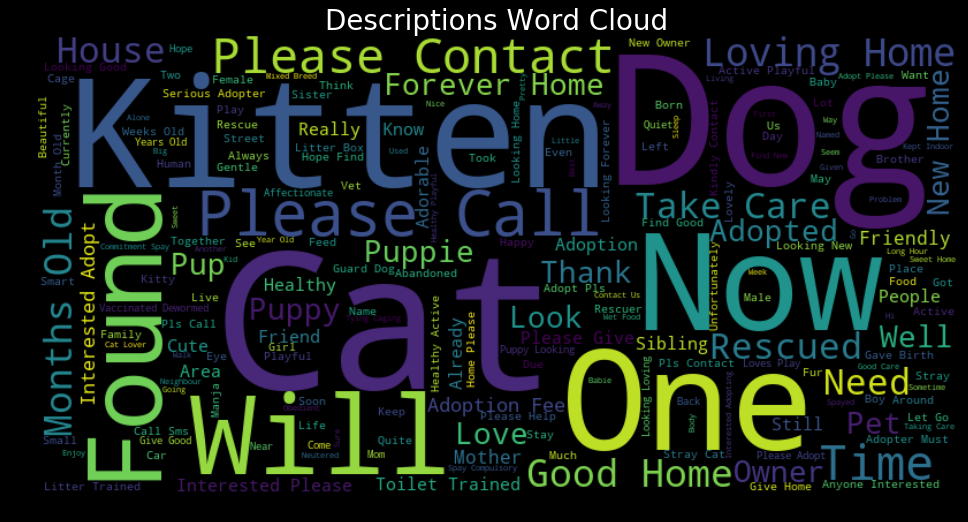

In [5]:
cloud(train.loc[:,"Description"].str.title(), title="{}".format("Descriptions Word Cloud"), size=[12,8])

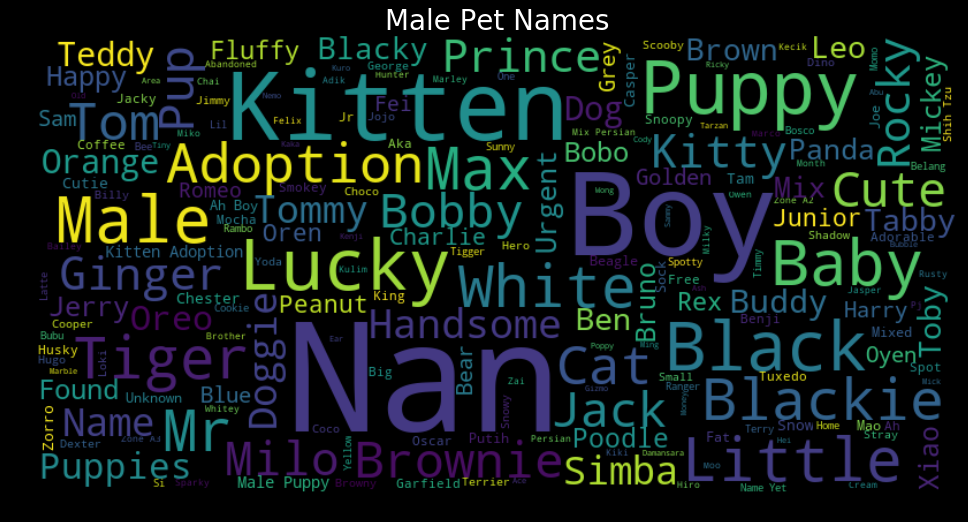

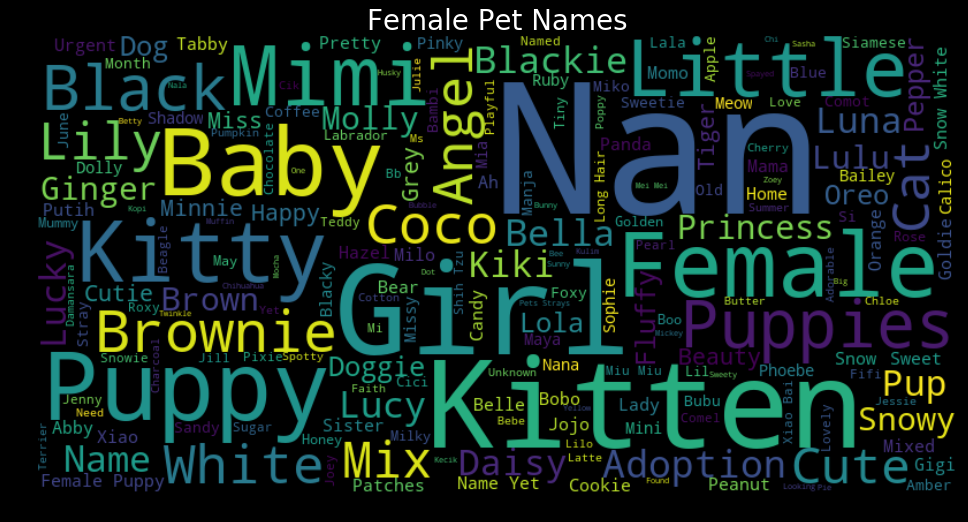

In [6]:
for i,name in [(1,"Male"),(2,"Female")]:
     cloud(train.loc[train.Gender == i,"Name"].str.title(), title="{} Pet Names".format(name), size=[12,8])

***

### Sentiment Data

In [7]:
samplesentiment = pd.read_json('../input/train_sentiment/{}'.format("4fdebca57.json"), orient='index', typ='series')
print("Document Sentiment")
print(samplesentiment["documentSentiment"])
print("\nEntities")
print(samplesentiment["entities"][0])
print("\nSentences")
print(samplesentiment['sentences'][0])

Document Sentiment
{'magnitude': 1.1, 'score': 0.5}

Entities
{'name': 'puppy', 'type': 'OTHER', 'metadata': {}, 'salience': 0.72392815, 'mentions': [{'text': {'content': 'puppy', 'beginOffset': -1}, 'type': 'COMMON'}]}

Sentences
{'text': {'content': 'Lovely puppy looking for a forever home.', 'beginOffset': -1}, 'sentiment': {'magnitude': 0.9, 'score': 0.9}}


In [8]:
with timer("Process Sentiment Train Data"):
    sentiment_list = os.listdir('../input/train_sentiment')
    train_sentiment_df = pd.DataFrame()
    for i,x in enumerate(sentiment_list):
        samplesentiment = pd.read_json('../input/train_sentiment/{}'.format(x), orient='index', typ='series')

        sentences = json_normalize(samplesentiment.sentences).loc[:,['sentiment.magnitude', 'sentiment.score']].agg(
                        {
                           'sentiment.magnitude' : ['count','mean','std'],
                           'sentiment.score' : ['mean','std', 'sum']

                        }).unstack().to_frame().sort_index(level=1).T
        sentences.columns = sentences.columns.map('_'.join)

#         words_salience_type = json_normalize(samplesentiment.entities).loc[:,['name','salience','type']].set_index('name')\
#             .unstack().to_frame().sort_index(level=1).T
#         words_salience_type.columns = words_salience_type.columns.map('_'.join)

        sentiment = pd.concat([json_normalize(samplesentiment["documentSentiment"]),
                               sentences,
#                                words_salience_type
                              ], axis =1)
#         train_sentiment_df[x[:9]] = sentiment
        sentiment.index = [x[:9]]
        train_sentiment_df = pd.concat([train_sentiment_df, sentiment], axis =0)

    display(train_sentiment_df.sample(5))
    train = train.join(train_sentiment_df, on = "PetID")
    del train_sentiment_df

,magnitude,score,sentiment.magnitude_count,sentiment.score_count,sentiment.magnitude_mean,sentiment.score_mean,sentiment.magnitude_std,sentiment.score_std,sentiment.magnitude_sum,sentiment.score_sum
2d2f6b042,3.1,0.4,4.0,NaN,0.725000,0.425000,0.150000,0.694622,NaN,1.7
bb2e480f4,0.7,0.3,2.0,NaN,0.300000,0.300000,0.424264,0.424264,NaN,0.6
718c4b524,6.3,0.3,11.0,NaN,0.518182,0.281818,0.309251,0.551032,NaN,3.1
0d25fb291,3.0,0.4,5.0,NaN,0.540000,0.380000,0.350714,0.554076,NaN,1.9
dcd70e1e3,1.6,0.8,2.0,NaN,0.800000,0.800000,0.000000,0.000000,NaN,1.6


[Process Sentiment Train Data] done in 264 s


In [9]:
with timer("Process Sentiment Test Data"):
    sentiment_list = os.listdir('../input/test_sentiment/')
    test_sentiment_df = pd.DataFrame()
    for i,x in enumerate(sentiment_list):
        samplesentiment = pd.read_json('../input/test_sentiment/{}'.format(x), orient='index', typ='series')
        sentences = json_normalize(samplesentiment.sentences).loc[:,['sentiment.magnitude', 'sentiment.score']].agg(
                        {
                           'sentiment.magnitude' : ['count','mean','std'],
                           'sentiment.score' : ['mean','std', 'sum']

                        }).unstack().to_frame().sort_index(level=1).T
        sentences.columns = sentences.columns.map('_'.join)

#         words_salience_type = json_normalize(samplesentiment.entities).loc[:,['name','salience','type']].set_index('name')\
#             .unstack().to_frame().sort_index(level=1).T
#         words_salience_type.columns = words_salience_type.columns.map('_'.join)

        sentiment = pd.concat([json_normalize(samplesentiment["documentSentiment"]),
                               sentences,
#                                words_salience_type
                              ], axis =1)
#         test_sentiment_df[x[:9]] = sentiment
        sentiment.index = [x[:9]]
        test_sentiment_df = pd.concat([test_sentiment_df, sentiment], axis =0)

    display(test_sentiment_df.sample(5))

    test = test.join(test_sentiment_df, on = "PetID")
    del test_sentiment_df

,magnitude,score,sentiment.magnitude_count,sentiment.score_count,sentiment.magnitude_mean,sentiment.score_mean,sentiment.magnitude_std,sentiment.score_std,sentiment.magnitude_sum,sentiment.score_sum
926622f1b,1.3,0.2,5.0,NaN,0.220000,0.220000,0.349285,0.349285,NaN,1.1
eef9bca7e,0.0,0.0,1.0,NaN,0.000000,0.000000,NaN,NaN,NaN,0.0
e17644953,2.6,0.2,6.0,NaN,0.400000,0.300000,0.400000,0.493964,NaN,1.8
d9362f7f1,0.9,0.2,2.0,NaN,0.450000,0.250000,0.353553,0.636396,NaN,0.5
54ffef406,0.8,0.2,3.0,NaN,0.233333,0.233333,0.115470,0.115470,NaN,0.7


[Process Sentiment Test Data] done in 69 s


### Image Metadata

Not using this, just for exploration.

In [10]:
sample_image_metadata = pd.read_json('../input/train_metadata/{}'.format("c161afd26-3.json"), orient='index', typ='series')

print("Label Annotations")
print(sample_image_metadata['labelAnnotations'])
print("\nImage Properties Annotations")
print(sample_image_metadata['imagePropertiesAnnotation'])
print("\nCrop Hints Annotation")
print(sample_image_metadata['cropHintsAnnotation'])

Label Annotations
[{'mid': '/m/01yrx', 'description': 'cat', 'score': 0.9443672999999999, 'topicality': 0.9443672999999999}, {'mid': '/m/07k6w8', 'description': 'small to medium sized cats', 'score': 0.9133557, 'topicality': 0.9133557}, {'mid': '/m/0307l', 'description': 'cat like mammal', 'score': 0.84403306, 'topicality': 0.84403306}, {'mid': '/m/01z5f', 'description': 'dog like mammal', 'score': 0.81212914, 'topicality': 0.81212914}, {'mid': '/m/02x9dk', 'description': 'boston terrier', 'score': 0.77335393, 'topicality': 0.77335393}, {'mid': '/m/01lrl', 'description': 'carnivoran', 'score': 0.72956854, 'topicality': 0.72956854}, {'mid': '/m/0c_jw', 'description': 'furniture', 'score': 0.6081759999999999, 'topicality': 0.6081759999999999}, {'mid': '/m/02xl47d', 'description': 'dog breed group', 'score': 0.59514534, 'topicality': 0.59514534}, {'mid': '/m/01l7qd', 'description': 'whiskers', 'score': 0.55154145, 'topicality': 0.55154145}, {'mid': '/m/08xf1x', 'description': 'non sportin

### Text and Breed Processing

In [11]:
train.set_index("PetID", inplace= True)
test.set_index("PetID", inplace= True)

traindex = train.index
testdex = test.index

y = train.AdoptionSpeed
train.drop('AdoptionSpeed', axis =1 , inplace=True)

df = pd.concat([train,test], axis = 0)

# Join Breed Dataset
df = df.merge(breed_label, left_on = 'Breed1', right_on = 'BreedID', how = 'left', suffixes = ['','b1']).drop('BreedID',axis=1)
df.rename(columns = {'BreedName':'b1name'}, inplace=True)
df = df.merge(breed_label, left_on = 'Breed2', right_on = 'BreedID', how = 'left', suffixes = ['','b2']).drop('BreedID',axis=1)
df.rename(columns = {'BreedName':'b2name'}, inplace=True)

#### Label Encoding

In [12]:
print("Encode Variables")
categorical = ["Name"]
print("Encoding :",categorical)

df.Name = df.Name.str.lower()

# Encoder:
lbl = preprocessing.LabelEncoder()
for col in categorical:
    df["encoded_" + col] = lbl.fit_transform(df[col].astype(str))
    
df.drop('RescuerID', axis =1 ,inplace=True)

Encode Variables
Encoding : ['Name']


#### Meta Text Feautres

In [13]:
textfeats = ["Description"]

for cols in textfeats:
    df[cols] = df[cols].astype(str) 
    df[cols] = df[cols].astype(str).fillna('missing') # FILL NA
    df[cols] = df[cols].str.lower() # Lowercase all text, so that capitalized words dont get treated differently
    df[cols + '_num_words'] = df[cols].apply(lambda comment: len(comment.split())) # Count number of Words
    df[cols + '_num_unique_words'] = df[cols].apply(lambda comment: len(set(w for w in comment.split())))
    df[cols + '_words_vs_unique'] = df[cols+'_num_unique_words'] / df[cols+'_num_words'] * 100 # Count Unique Words

In [14]:
# Combine Secondary Text Features into one
df['name_and_breeds'] = df['Name'].astype(str) + ' ' +  df['b1name'].astype(str) + ' ' + df['b2name'].astype(str)
df['name_and_breeds'] = df['name_and_breeds'].str.lower()

df.drop(['Name', 'b1name','b2name'], axis =1, inplace= True)

#### TF-IDF

In [15]:
# Distinguish Train / Test
train = df.iloc[0:len(traindex),:]
test = df.iloc[len(traindex):,:]
del df; gc.collect();

In [16]:
word_vect = TfidfVectorizer(
            sublinear_tf=True,
            strip_accents='unicode',
            analyzer='word',
            token_pattern=r'\w{1,}',
            stop_words='english',
            ngram_range=(1, 2),
            max_features=20000)

char_vectorizer = TfidfVectorizer(
            sublinear_tf=True,
            strip_accents='unicode',
            analyzer='word',
            ngram_range=(2,5),
            max_features=3000)

with timer("Word Grams TFIDF"):
    word_vect.fit(train['Description'])
    train_word_features  = word_vect.transform(train['Description'])
    test_word_features  = word_vect.transform(test['Description'])

with timer("Character Grams TFIDF"):
    char_vectorizer.fit(train['name_and_breeds'])
    train_char_features = char_vectorizer.transform(train['name_and_breeds'])
    test_char_features = char_vectorizer.transform(test['name_and_breeds'])

# Get Structured Data    
num_features = [f_ for f_ in train.columns
            if f_ not in ["Description", "name_and_breeds"]]
    
# Get Sparse Matrix Feature Names..
feature_names = (word_vect.get_feature_names() +
                char_vectorizer.get_feature_names() +
                num_features)

with timer("Sparse Combine"):
    X = hstack(
        [
            train_char_features,
            train_word_features,
            train[num_features]
        ]
    ).tocsr()

    del train_char_features
    gc.collect()

    testing = hstack(
        [
            test_char_features,
            test_word_features,
            test[num_features]
        ]
    ).tocsr()
# del train, test
del test_char_features; gc.collect()

[Word Grams TFIDF] done in 4 s
[Character Grams TFIDF] done in 1 s
[Sparse Combine] done in 0 s


0

## LGBM

In [17]:
for shape in [X,testing]:
    print("{} Rows and {} Cols".format(*shape.shape))
    
print("Feature Count:", len(feature_names))
print("Dependent Variable Len", y.shape[0])

continuous_vars = ['Age','Quantity', 'Fee',
       'VideoAmt', 'PhotoAmt', 'magnitude', 'score',
       'sentiment.magnitude_count', 'sentiment.score_count',
       'sentiment.magnitude_mean', 'sentiment.score_mean',
       'sentiment.magnitude_std', 'sentiment.score_std',
       'sentiment.magnitude_sum', 'sentiment.score_sum', 'Description_num_words',
       'Description_num_unique_words','Description_words_vs_unique']
categorical_vars = [x for x in num_features if x not in continuous_vars]

14993 Rows and 23035 Cols
3972 Rows and 23035 Cols
Feature Count: 23035
Dependent Variable Len 14993


In [18]:
lgtrain = lgb.Dataset(X, label=y, feature_name= feature_names,
                      free_raw_data=False, categorical_feature = categorical_vars)
feature_importance_df = pd.DataFrame()
n_fold = 0
print("Light Gradient Boosting Classifier: ")

lgbm_params = {
          'application': 'regression',
          'boosting': 'gbdt',
          'metric': 'rmse',
          'num_leaves': 150,
          'max_depth': -1,
          'learning_rate': 0.01,
          'bagging_fraction': 0.85,
          'feature_fraction': 0.8,
          'min_split_gain': 0.01,
          'min_child_samples': 150,
          'min_child_weight': 0.1,
          'verbosity': -1,
          'data_random_seed': 3,
          'early_stop': 100,
          'verbose_eval': 100,
          'num_rounds': 3000}

folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)
fold_preds = np.zeros((testing.shape[0],))
oof_preds = np.zeros((X.shape[0],))
all_coefficients = np.zeros((5, 4))
lgtrain.construct()

# Fit 5 Folds
modelstart = time.time()
for trn_idx, val_idx in folds.split(X, y):
    clf = lgb.train(
        params=lgbm_params,
        train_set=lgtrain.subset(trn_idx),
        valid_sets=lgtrain.subset(val_idx),
        categorical_feature = categorical_vars,
        num_boost_round=1500, 
        early_stopping_rounds=150,
        verbose_eval=300
    )
    fold_importance_df = pd.DataFrame()
    fold_importance_df["feature"] = feature_names
    fold_importance_df["importance"] = clf.feature_importance(importance_type='gain')
    fold_importance_df["fold"] = n_fold + 1
    feature_importance_df = pd.concat([feature_importance_df, fold_importance_df], axis=0)
    
    # Creds to Abhishek
    # https://www.kaggle.com/abhishek/maybe-something-interesting-here/notebook
    pred_test_y = clf.predict(X[val_idx], num_iteration=clf.best_iteration)
    optR = OptimizedRounder()
    optR.fit(pred_test_y, y.iloc[val_idx].values)
    coefficients = optR.coefficients()
    pred_test_y_k = optR.predict(pred_test_y, coefficients)
    all_coefficients[n_fold, :] = coefficients
    print("Valid Counts = ", Counter(y.iloc[val_idx].values))
    print("Predicted Counts = ", Counter(pred_test_y_k))
    print("Coefficients = ", coefficients)
    qwk = quadratic_weighted_kappa(y.iloc[val_idx].values, pred_test_y_k)
    print("QWK = ", qwk)
    print('Predict 2/2')
#     pred_test_y2 = model.predict(test_X2, num_iteration=model.best_iteration)
    fold_preds += clf.predict(testing, num_iteration=clf.best_iteration) / folds.n_splits
    n_fold += 1

print("Model Runtime: %0.2f Minutes"%((time.time() - modelstart)/60))

Light Gradient Boosting Classifier: 


/opt/conda/lib/python3.6/site-packages/lightgbm/engine.py:116: UserWarning: Found `num_rounds` in params. Will use it instead of argument
  warnings.warn("Found `{}` in params. Will use it instead of argument".format(alias))


Training until validation scores don't improve for 150 rounds.
[300]	valid_0's rmse: 1.05167
[600]	valid_0's rmse: 1.03879
[900]	valid_0's rmse: 1.03622
Early stopping, best iteration is:
[867]	valid_0's rmse: 1.03593
Valid Counts =  Counter({4: 840, 2: 808, 3: 652, 1: 618, 0: 82})
Predicted Counts =  Counter({2.0: 863, 3.0: 807, 4.0: 753, 1.0: 577})
Coefficients =  [0.51064749 2.0103746  2.46085845 2.91544471]
QWK =  0.4608560695578561
Predict 2/2


/opt/conda/lib/python3.6/site-packages/lightgbm/engine.py:116: UserWarning: Found `num_rounds` in params. Will use it instead of argument
  warnings.warn("Found `{}` in params. Will use it instead of argument".format(alias))


Training until validation scores don't improve for 150 rounds.
[300]	valid_0's rmse: 1.06588
[600]	valid_0's rmse: 1.05462
[900]	valid_0's rmse: 1.05112
[1200]	valid_0's rmse: 1.05035
[1500]	valid_0's rmse: 1.04982
[1800]	valid_0's rmse: 1.04945
Early stopping, best iteration is:
[1689]	valid_0's rmse: 1.0493
Valid Counts =  Counter({4: 840, 2: 808, 3: 652, 1: 618, 0: 82})
Predicted Counts =  Counter({2.0: 1283, 4.0: 767, 3.0: 686, 1.0: 264})
Coefficients =  [0.49896491 1.73273929 2.51444866 2.90189662]
QWK =  0.4199689423132227
Predict 2/2


...

Training until validation scores don't improve for 150 rounds.
[300]	valid_0's rmse: 1.06352
[600]	valid_0's rmse: 1.05542
Early stopping, best iteration is:
[648]	valid_0's rmse: 1.05517
Valid Counts =  Counter({4: 839, 2: 807, 3: 652, 1: 618, 0: 82})
Predicted Counts =  Counter({2.0: 1123, 3.0: 854, 4.0: 687, 1.0: 334})
Coefficients =  [0.54811565 1.87849666 2.47877271 2.93786689]
QWK =  0.414486812739184
Predict 2/2


/opt/conda/lib/python3.6/site-packages/lightgbm/engine.py:116: UserWarning: Found `num_rounds` in params. Will use it instead of argument
  warnings.warn("Found `{}` in params. Will use it instead of argument".format(alias))


Training until validation scores don't improve for 150 rounds.
[300]	valid_0's rmse: 1.06767
[600]	valid_0's rmse: 1.05749
[900]	valid_0's rmse: 1.05543
Early stopping, best iteration is:
[1042]	valid_0's rmse: 1.05515
Valid Counts =  Counter({4: 839, 2: 807, 3: 652, 1: 618, 0: 82})
Predicted Counts =  Counter({2.0: 1063, 4.0: 758, 3.0: 640, 1.0: 536, 0.0: 1})
Coefficients =  [0.52676008 1.96058658 2.5205557  2.8898527 ]
QWK =  0.4262926150650146
Predict 2/2


/opt/conda/lib/python3.6/site-packages/lightgbm/engine.py:116: UserWarning: Found `num_rounds` in params. Will use it instead of argument
  warnings.warn("Found `{}` in params. Will use it instead of argument".format(alias))


Training until validation scores don't improve for 150 rounds.
[300]	valid_0's rmse: 1.05876
[600]	valid_0's rmse: 1.04969
[900]	valid_0's rmse: 1.04813
Early stopping, best iteration is:
[985]	valid_0's rmse: 1.0476
Valid Counts =  Counter({4: 839, 2: 807, 3: 651, 1: 618, 0: 82})
Predicted Counts =  Counter({2.0: 1169, 3.0: 799, 4.0: 662, 1.0: 367})
Coefficients =  [0.4512878  1.88270841 2.48810233 2.94238154]
QWK =  0.42955056069257513
Predict 2/2
Model Runtime: 3.43 Minutes


/opt/conda/lib/python3.6/site-packages/scipy/stats/stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


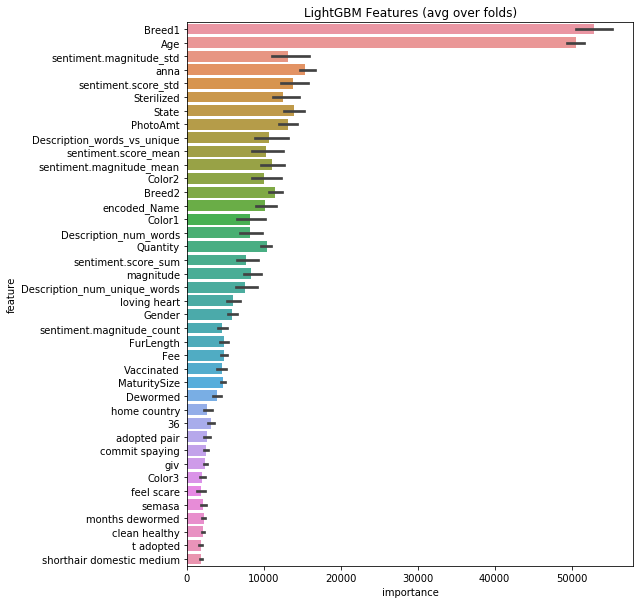

In [19]:
def display_importances(feature_importance_df_):
    cols = feature_importance_df_[["feature", "importance"]].groupby("feature").mean().sort_values(by="importance", ascending=False)[:40].index
    best_features = feature_importance_df_.loc[feature_importance_df_.feature.isin(cols)]
    plt.figure(figsize=(8, 10))
    sns.barplot(x="importance", y="feature", data=best_features.sort_values(by="importance", ascending=False))
    plt.title('LightGBM Features (avg over folds)')
    plt.tight_layout
    plt.savefig('lgbm_importances01.png')
display_importances(feature_importance_df)

In [20]:
optR = OptimizedRounder()
coefficients_ = np.mean(all_coefficients, axis=0)
print(coefficients_)

optR = OptimizedRounder()
test_predictions = optR.predict(fold_preds, coefficients_).astype(int)
Counter(test_predictions)

# quadratic_weighted_kappa(target, train_predictions)
# rmse(target, [r[0] for r in results['train']])
submission = pd.DataFrame({'PetID': testdex, 'AdoptionSpeed': test_predictions})
submission.to_csv('submission.csv', index=False)
submission.head()

[0.50715518 1.89298111 2.49254757 2.91748849]


,PetID,AdoptionSpeed
0,e2dfc2935,3
1,f153b465f,2
2,3c90f3f54,2
3,e02abc8a3,4
4,09f0df7d1,3


In [21]:
print("Train Dependent Variable Class Distribution:\n", y.value_counts())
print("Prediction Dependent Variable Class Distribution:\n", submission['AdoptionSpeed'].value_counts())

print("Notebook Runtime: %0.2f Minutes"%((time.time() - notebookstart)/60))

Train Dependent Variable Class Distribution:
 4    4197
2    4037
3    3259
1    3090
0     410
Name: AdoptionSpeed, dtype: int64
Prediction Dependent Variable Class Distribution:
 2    1449
4    1166
3     962
1     395
Name: AdoptionSpeed, dtype: int64
Notebook Runtime: 9.29 Minutes
